In [1]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

import matplotlib.pyplot as plt

from cubes import set_r_cube
from generate_goldreich_sridhar import get_aniso_cube

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines

In [ ]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side
k_min = 2*np.pi/(2*L)  # [pc-1], full wavelength in the cube

print(f"Each cell is a cube with size {dx:.2f} pc")
print(f"Injection scale corresponds to {2*np.pi/k_min:.2f} pc")

r_cube = set_r_cube(n_side, L)

Each cell is a cube with size 2.34 pc
Injection scale corresponds to 600.00 pc


In [3]:
b_cube = get_aniso_cube(n_side, L, k_min, model='YL02')

In [4]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube)

In [5]:
ds = dx / 5
n_steps = int(L / ds)  # n_steps

In [6]:
M = 100
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

In [7]:
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

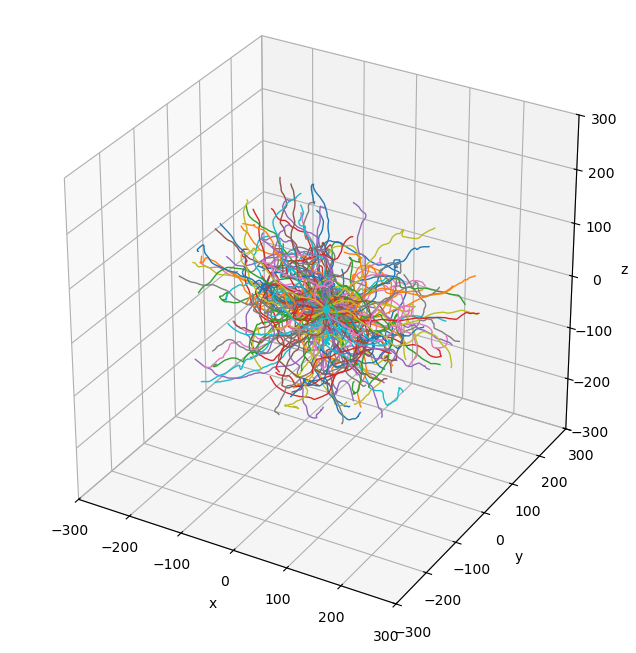

In [8]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)